# Bayesian Networks: Probabilistic Inference with Graphical Models

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook provides a comprehensive introduction to Bayesian Networks (BNs), a powerful framework for reasoning under uncertainty using directed acyclic graphs (DAGs). We cover two classic examples: the Alarm network (Burglary/Earthquake) and the Sprinkler network (Wet Grass). The notebook demonstrates both library-based inference using `pgmpy` and a complete "from scratch" implementation of variable elimination.

**Key techniques & libraries:**
- `pgmpy` – Bayesian Network construction, CPDs, and Variable Elimination inference
- `numpy` – numerical computations for the from‑scratch implementation
- `matplotlib` and `networkx` – DAG visualisation
- Custom inference engine – demonstrates understanding of the mathematics

**Data source:**  
Synthetic probabilistic models defined within the notebook – no external data required.

**Link PGMPY:** https://pgmpy.org/models/bayesiannetwork.html

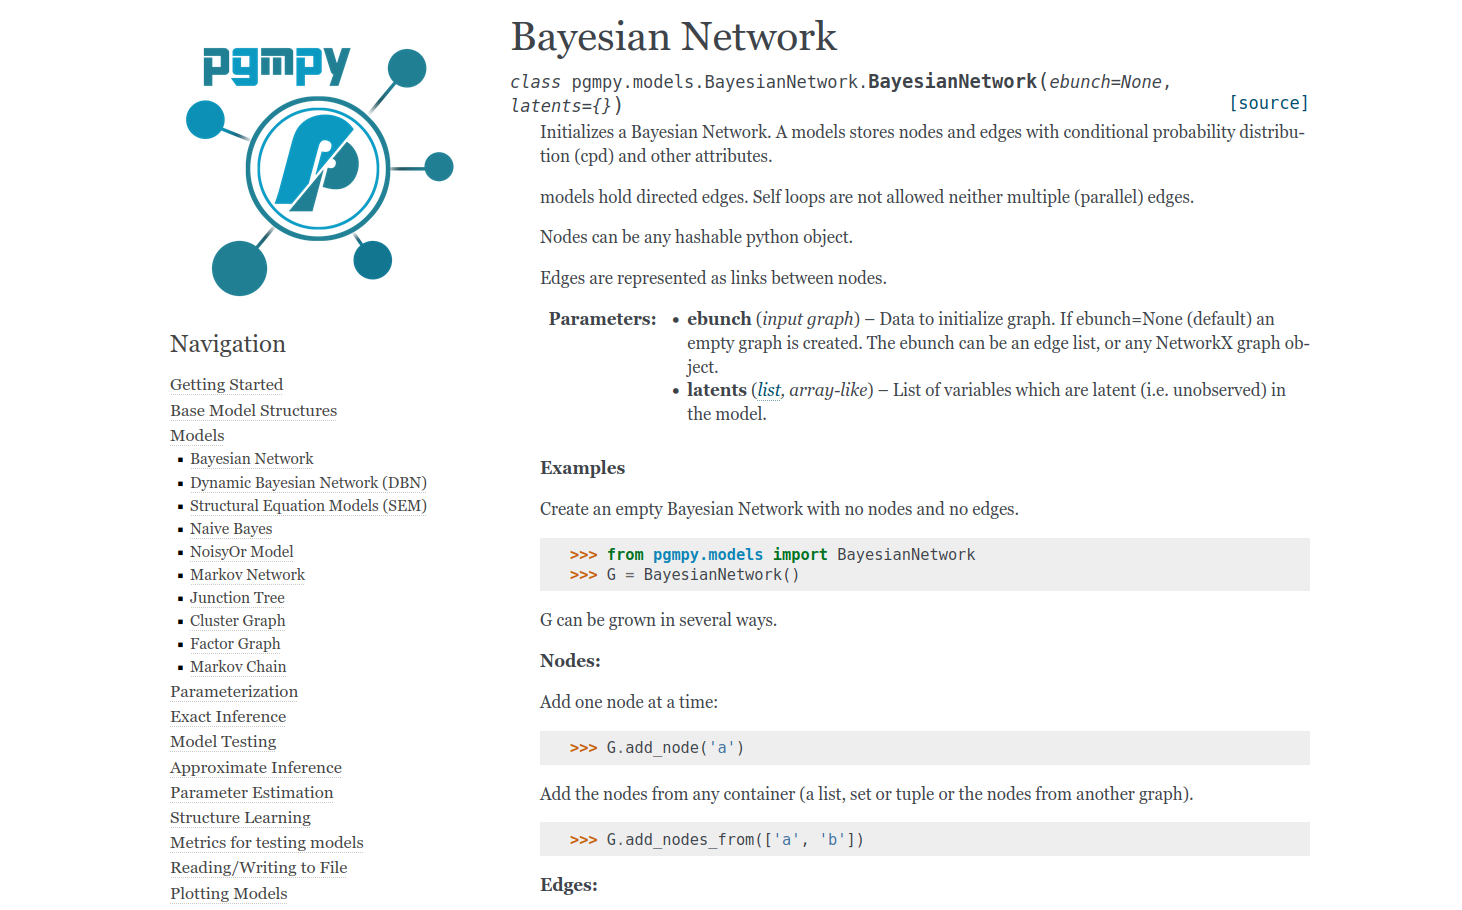

In [6]:
# Imports and configuration
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14

In [9]:
def plot_bayesian_network(model, title="Bayesian Network Structure", figsize=(10, 8)):
    """
    Plot the Directed Acyclic Graph (DAG) of a Bayesian Network.

    Args:
        model (DiscreteBayesianNetwork): The Bayesian Network model.
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    # Create a new DiGraph for visualization
    G = nx.DiGraph()
    
    # Add nodes from the model
    for node in model.nodes():
        G.add_node(node)
    
    # Add edges from the model
    for edge in model.edges():
        G.add_edge(edge[0], edge[1])
    
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=3000, font_size=10, font_weight='bold',
            arrowsize=20, edge_color='gray', arrows=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def print_cpd(cpd, label="Conditional Probability Table"):
    """
    Print a Conditional Probability Table in a readable format.

    Args:
        cpd (TabularCPD): The CPD to display.
        label (str): Label for the CPD.
    """
    print(f"\n{label}:")
    print(cpd)

def query_model(model, variables, evidence=None):
    """
    Perform inference on a Bayesian Network using Variable Elimination.

    Args:
        model (BayesianNetwork): The model.
        variables (list): Variables to query.
        evidence (dict, optional): Evidence to condition on.

    Returns:
        pd.DataFrame: Query results.
    """
    infer = VariableElimination(model)
    if evidence:
        result = infer.query(variables=variables, evidence=evidence)
    else:
        result = infer.query(variables=variables)
    return result

def validate_bayesian_network(model):
    """
    Validate that the Bayesian Network is correctly specified.

    Args:
        model (BayesianNetwork): The model to validate.

    Returns:
        bool: True if valid, raises AssertionError otherwise.
    """
    try:
        assert model.check_model()
        print("Model validation passed.")
        return True
    except AssertionError as e:
        print(f"Model validation failed: {e}")
        raise

## 1. The Alarm Network (Burglary / Earthquake Example)

The Alarm network is a classic Bayesian Network example. It models the probability of a house alarm going off given a burglary or an earthquake. The network structure is:

**Robo (Burglary) -> Alarma <- Terremoto (Earthquake)**
**Alarma -> JohnLlama (John calls)**
**Alarma -> MaryLlama (Mary calls)**

We first define the network structure and Conditional Probability Tables (CPTs) using `pgmpy`, then perform inference.

C:\Users\phabe\AppData\Local\Temp\ipykernel_18596\1694357348.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


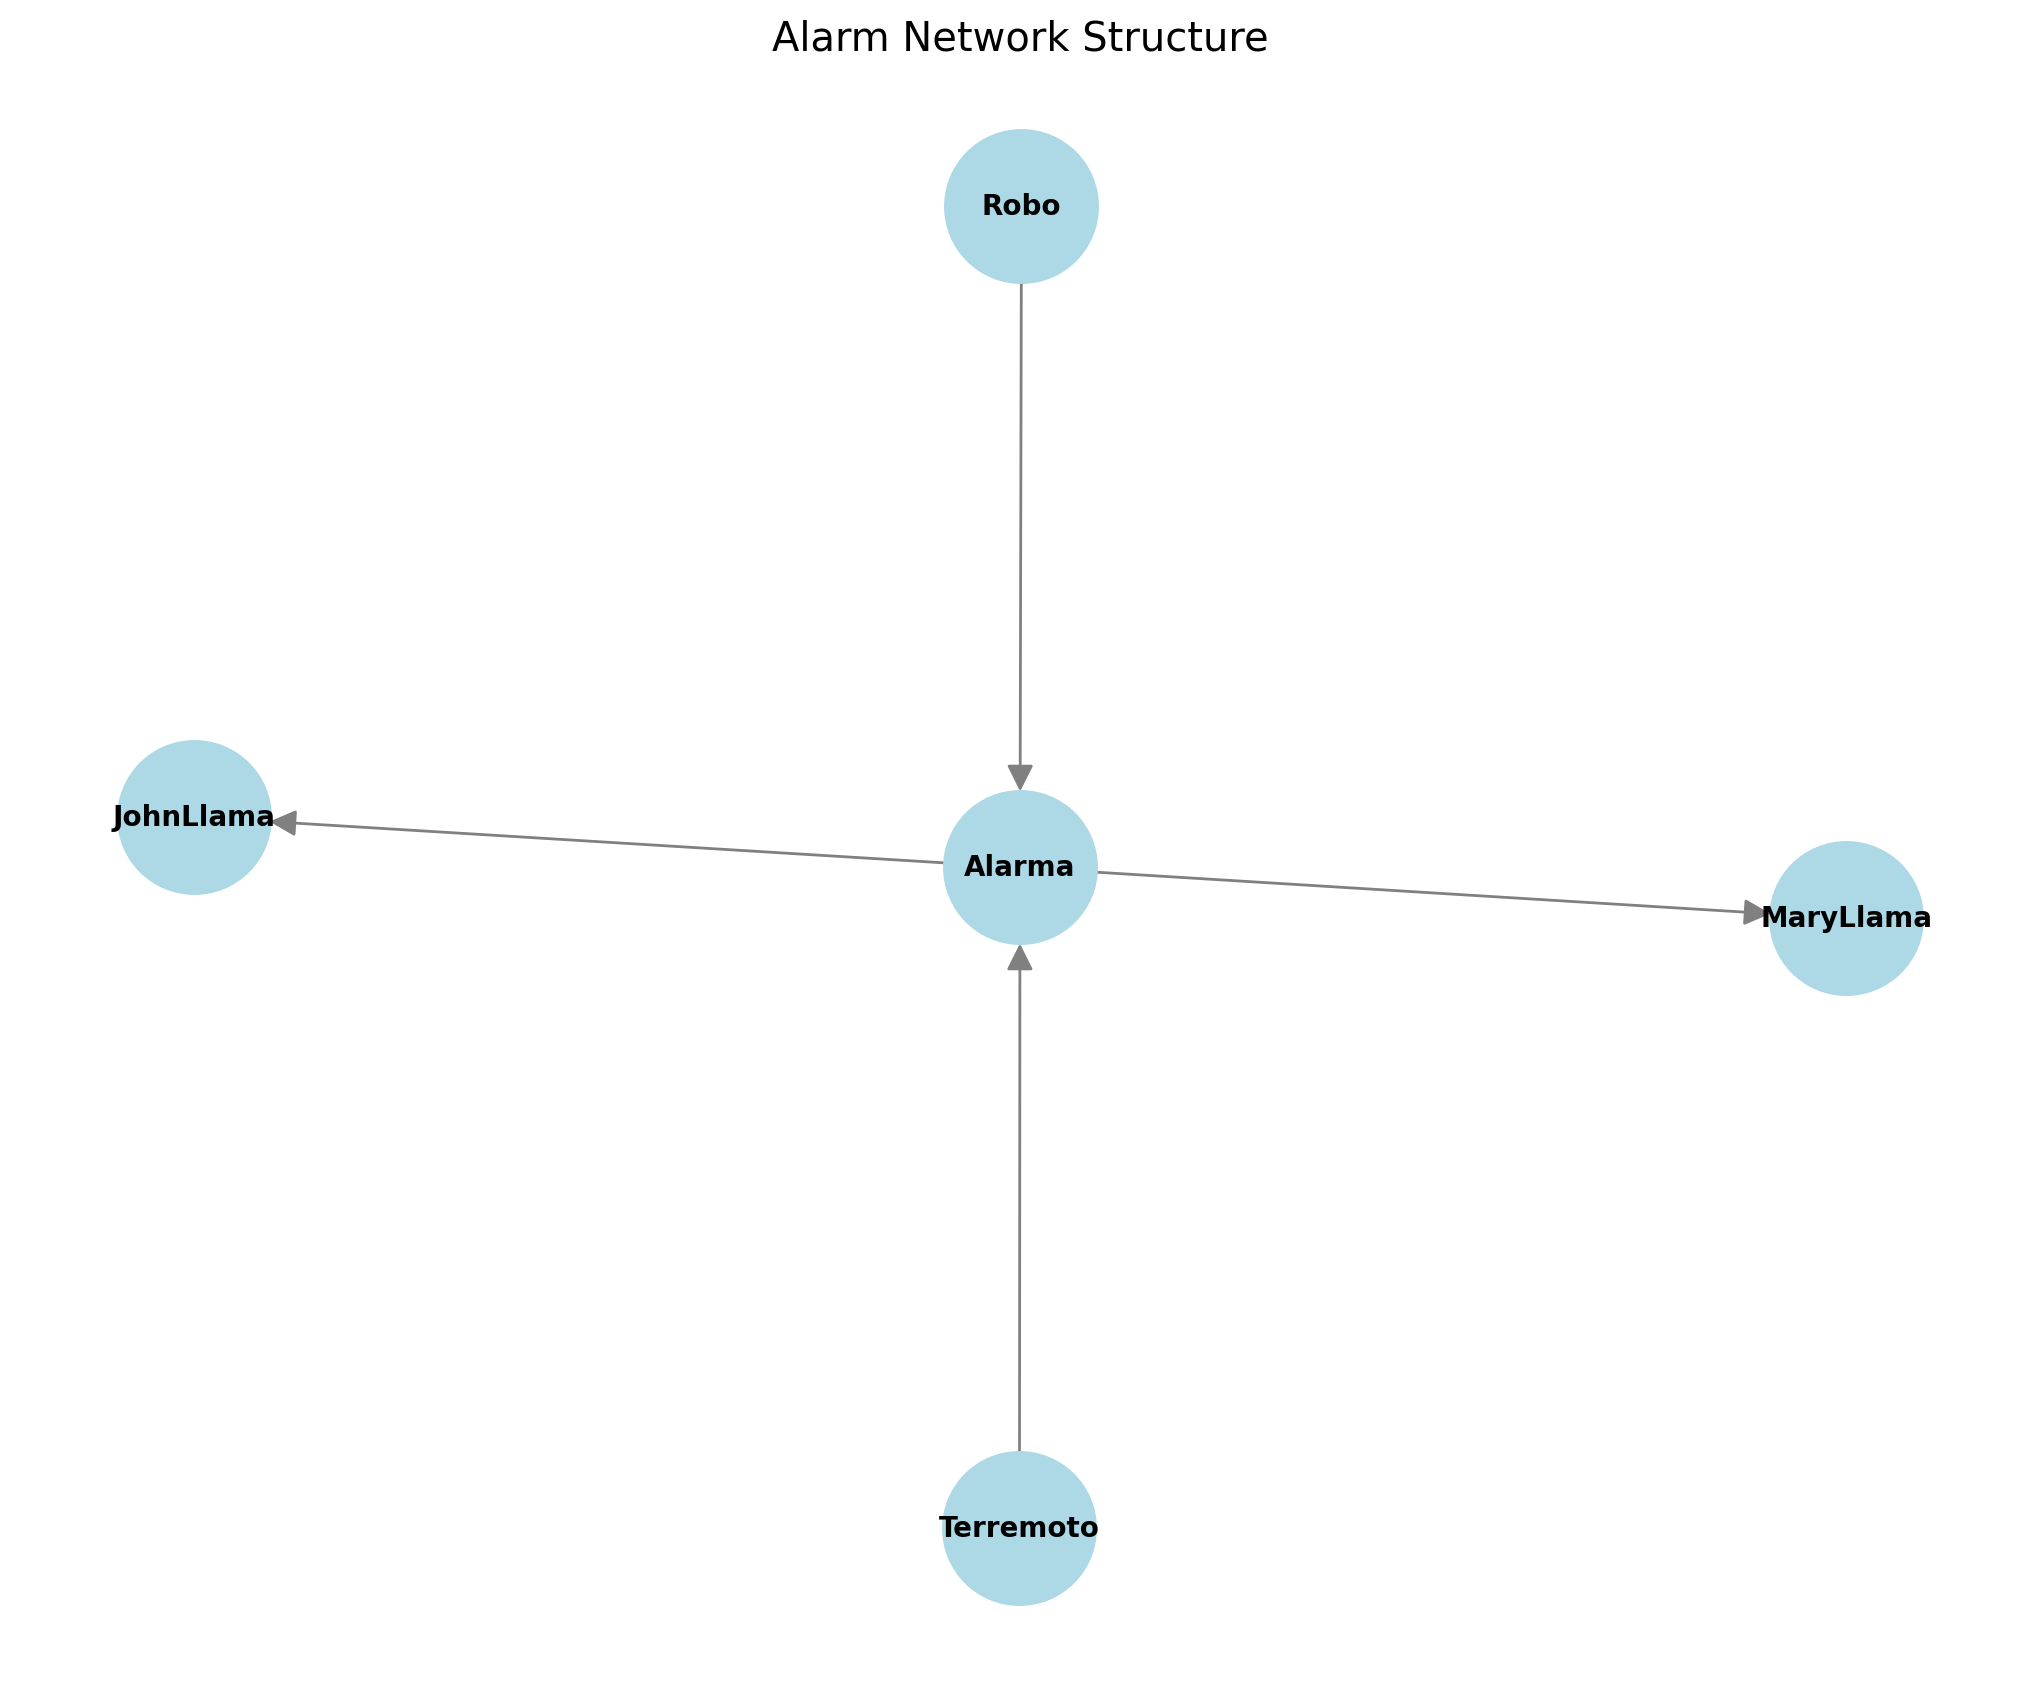

Model validation passed.


True

In [10]:
# Define the network structure
alarm_model = DiscreteBayesianNetwork([
    ('Robo', 'Alarma'),
    ('Terremoto', 'Alarma'),
    ('Alarma', 'JohnLlama'),
    ('Alarma', 'MaryLlama')
])

# Visualise the DAG
plot_bayesian_network(alarm_model, title="Alarm Network Structure")

# Define CPTs
# P(Robo)
cpd_robo = TabularCPD(
    variable='Robo', variable_card=2,
    values=[[0.999], [0.001]],
    state_names={'Robo': [False, True]}
)

# P(Terremoto)
cpd_terremoto = TabularCPD(
    variable='Terremoto', variable_card=2,
    values=[[0.998], [0.002]],
    state_names={'Terremoto': [False, True]}
)

# P(Alarma | Robo, Terremoto)
cpd_alarma = TabularCPD(
    variable='Alarma', variable_card=2,
    values=[[0.999, 0.71, 0.06, 0.05],
            [0.001, 0.29, 0.94, 0.95]],
    evidence=['Robo', 'Terremoto'],
    evidence_card=[2, 2],
    state_names={
        'Alarma': [False, True],
        'Robo': [False, True],
        'Terremoto': [False, True]
    }
)

# P(JohnLlama | Alarma)
cpd_john = TabularCPD(
    variable='JohnLlama', variable_card=2,
    values=[[0.95, 0.10],
            [0.05, 0.90]],
    evidence=['Alarma'],
    evidence_card=[2],
    state_names={
        'JohnLlama': [False, True],
        'Alarma': [False, True]
    }
)

# P(MaryLlama | Alarma)
cpd_mary = TabularCPD(
    variable='MaryLlama', variable_card=2,
    values=[[0.95, 0.10],
            [0.05, 0.90]],
    evidence=['Alarma'],
    evidence_card=[2],
    state_names={
        'MaryLlama': [False, True],
        'Alarma': [False, True]
    }
)

# Add CPTs to model
alarm_model.add_cpds(cpd_robo, cpd_terremoto, cpd_alarma, cpd_john, cpd_mary)

# Validate the model
validate_bayesian_network(alarm_model)

In [11]:
# Inference: P(Robo | JohnLlama=True, MaryLlama=True)
print("Query: P(Robo | JohnLlama=True, MaryLlama=True)")
result = query_model(
    alarm_model,
    variables=['Robo'],
    evidence={'JohnLlama': True, 'MaryLlama': True}
)
print(result)

# Additional inference: P(Alarma | JohnLlama=True, MaryLlama=True)
print("\nQuery: P(Alarma | JohnLlama=True, MaryLlama=True)")
result = query_model(
    alarm_model,
    variables=['Alarma'],
    evidence={'JohnLlama': True, 'MaryLlama': True}
)
print(result)

Query: P(Robo | JohnLlama=True, MaryLlama=True)
+-------------+-------------+
| Robo        |   phi(Robo) |
+=============+=============+
| Robo(False) |      0.8320 |
+-------------+-------------+
| Robo(True)  |      0.1680 |
+-------------+-------------+

Query: P(Alarma | JohnLlama=True, MaryLlama=True)
+---------------+---------------+
| Alarma        |   phi(Alarma) |
+===============+===============+
| Alarma(False) |        0.5502 |
+---------------+---------------+
| Alarma(True)  |        0.4498 |
+---------------+---------------+


## 2. The Sprinkler Network (Wet Grass Example)

The Sprinkler network models the probability of wet grass given rain or a sprinkler. The network structure is:

**Nublado (Cloudy) -> Aspersor (Sprinkler)**
**Nublado (Cloudy) -> Lluvia (Rain)**
**Aspersor (Sprinkler) -> HierbaMojada (Wet Grass)**
**Lluvia (Rain) -> HierbaMojada (Wet Grass)**

This example demonstrates inference with evidence (observing wet grass).

C:\Users\phabe\AppData\Local\Temp\ipykernel_18596\1694357348.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


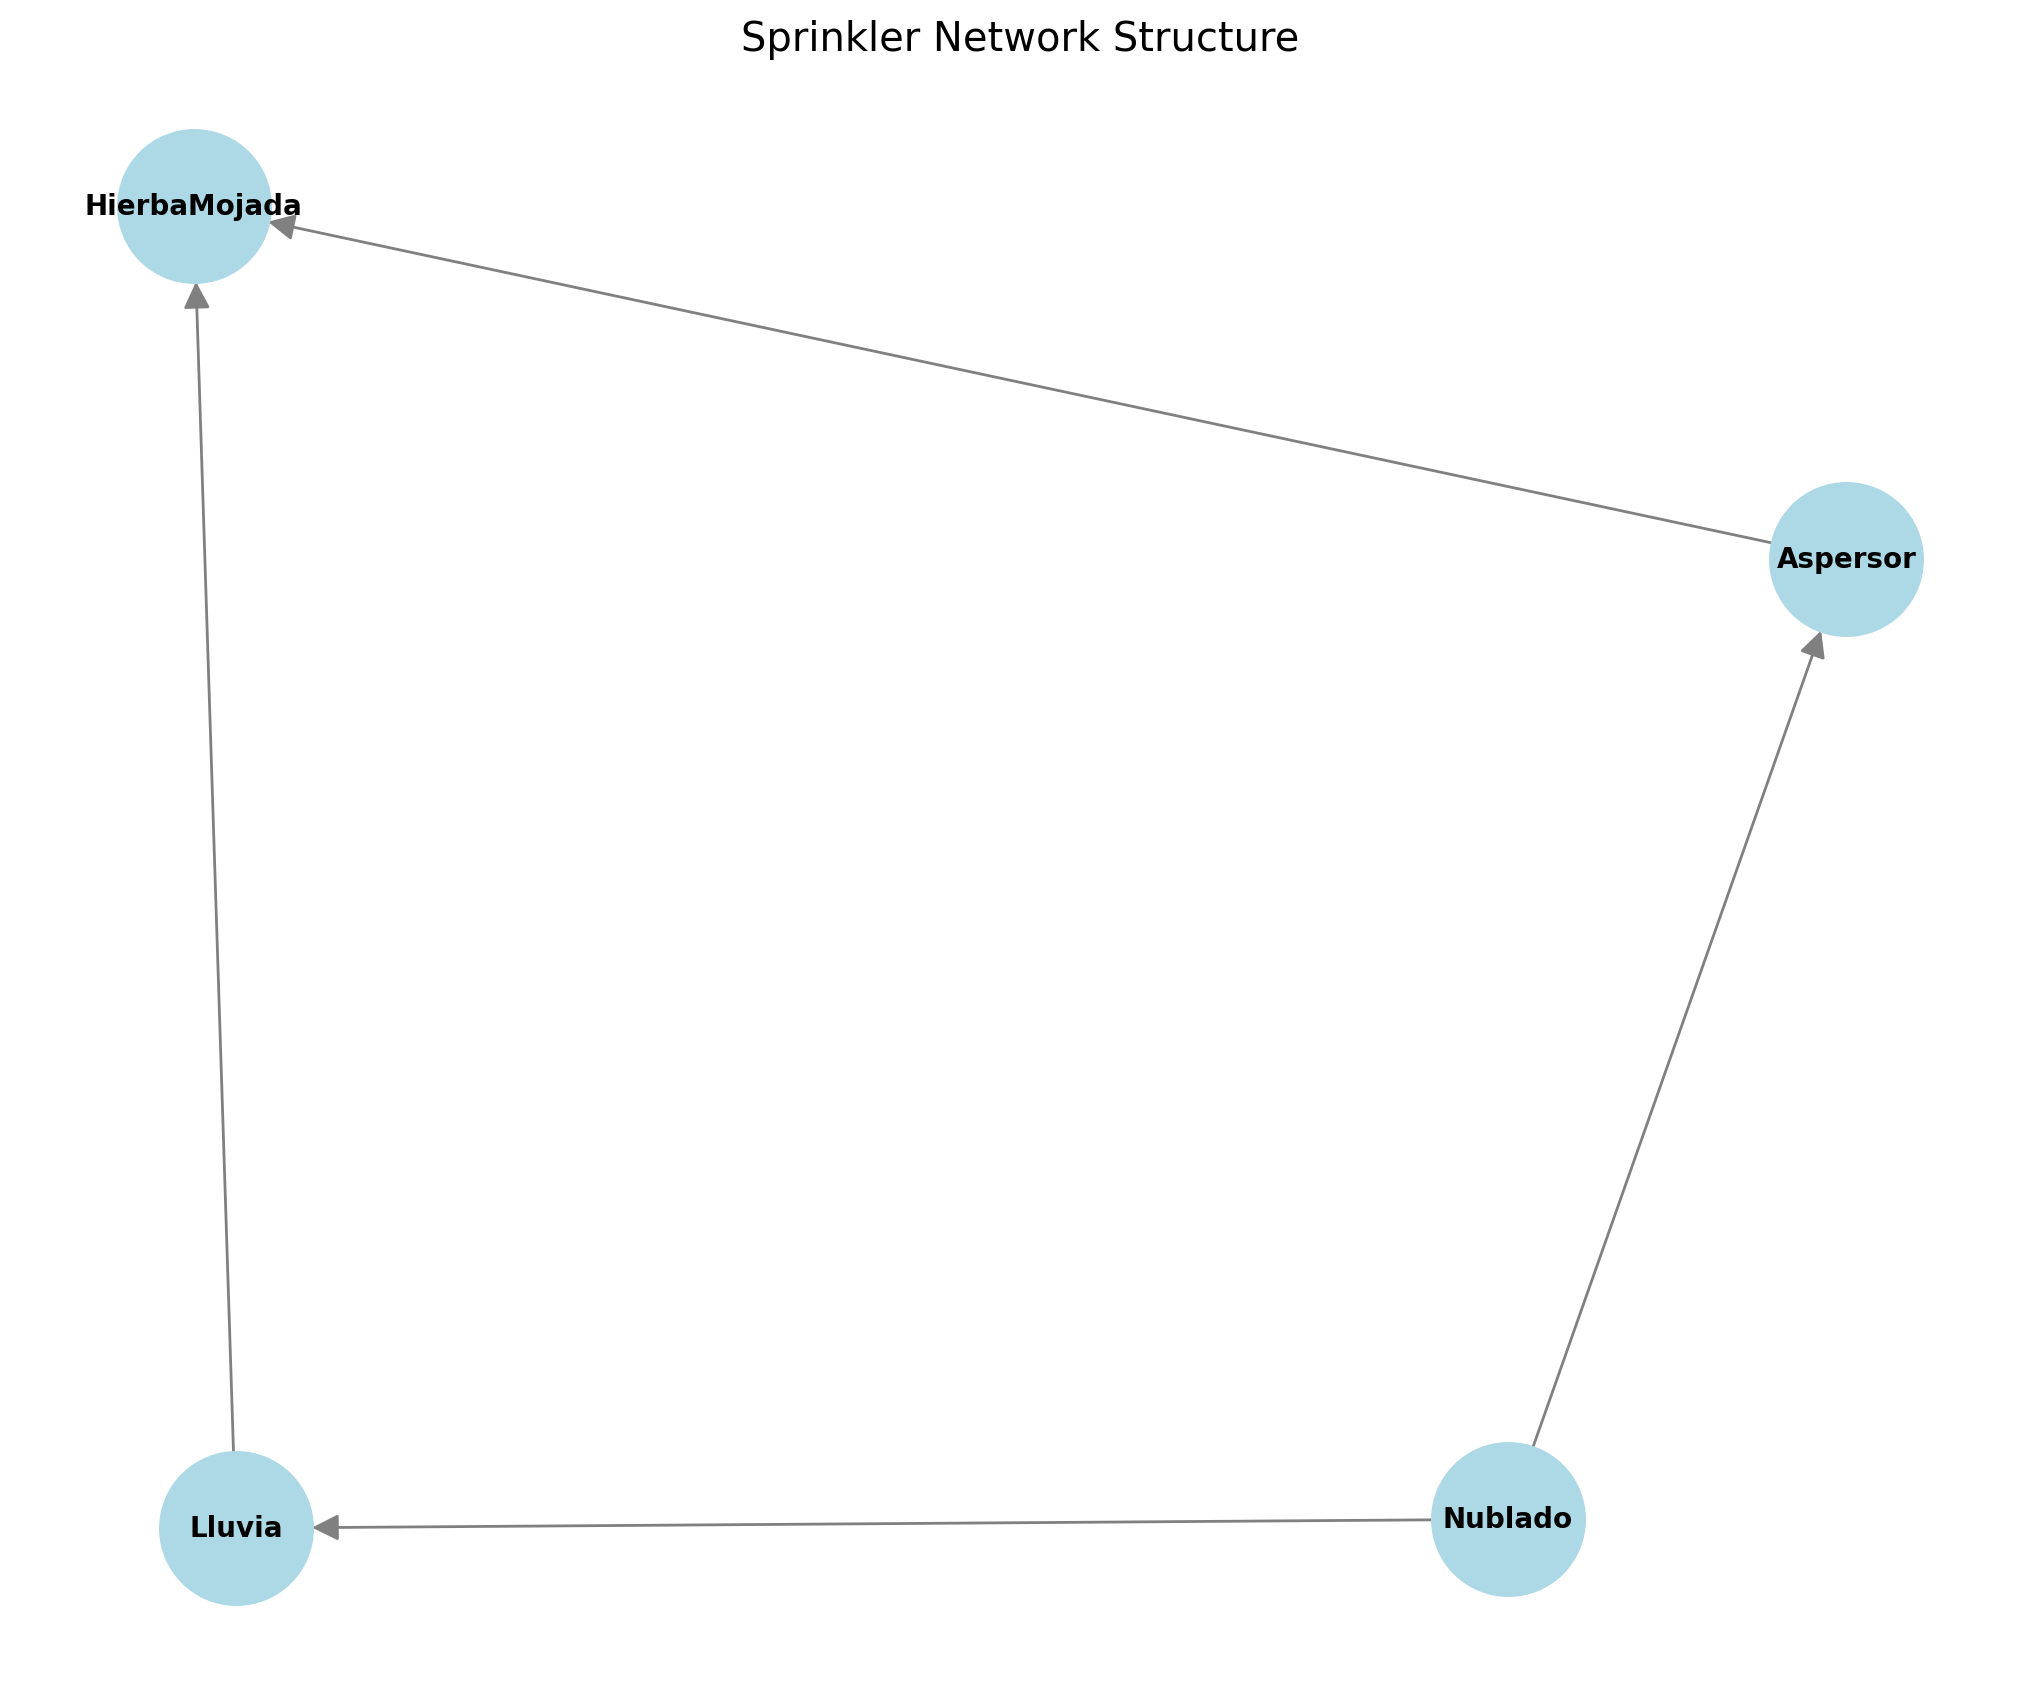

Model validation passed.


True

In [13]:
# Define the network structure
sprinkler_model = DiscreteBayesianNetwork([
    ('Nublado', 'Aspersor'),
    ('Nublado', 'Lluvia'),
    ('Aspersor', 'HierbaMojada'),
    ('Lluvia', 'HierbaMojada')
])

# Visualise the DAG
plot_bayesian_network(sprinkler_model, title="Sprinkler Network Structure")

# Define CPTs
# P(Nublado)
cpd_nublado = TabularCPD(
    variable='Nublado', variable_card=2,
    values=[[0.5], [0.5]],
    state_names={'Nublado': [False, True]}
)

# P(Aspersor | Nublado)
cpd_aspersor = TabularCPD(
    variable='Aspersor', variable_card=2,
    values=[[0.50, 0.90],
            [0.50, 0.10]],
    evidence=['Nublado'],
    evidence_card=[2],
    state_names={
        'Aspersor': [False, True],
        'Nublado': [False, True]
    }
)

# P(Lluvia | Nublado)
cpd_lluvia = TabularCPD(
    variable='Lluvia', variable_card=2,
    values=[[0.80, 0.20],
            [0.20, 0.80]],
    evidence=['Nublado'],
    evidence_card=[2],
    state_names={
        'Lluvia': [False, True],
        'Nublado': [False, True]
    }
)

# P(HierbaMojada | Aspersor, Lluvia)
cpd_hierba = TabularCPD(
    variable='HierbaMojada', variable_card=2,
    values=[[1.0, 0.10, 0.10, 0.01],
            [0.0, 0.90, 0.90, 0.99]],
    evidence=['Aspersor', 'Lluvia'],
    evidence_card=[2, 2],
    state_names={
        'HierbaMojada': [False, True],
        'Aspersor': [False, True],
        'Lluvia': [False, True]
    }
)

# Add CPTs to model
sprinkler_model.add_cpds(cpd_nublado, cpd_aspersor, cpd_lluvia, cpd_hierba)

# Validate the model
validate_bayesian_network(sprinkler_model)

In [14]:
# Inference: P(Lluvia | HierbaMojada=True)
print("Query: P(Lluvia | HierbaMojada=True)")
result = query_model(
    sprinkler_model,
    variables=['Lluvia'],
    evidence={'HierbaMojada': True}
)
print(result)

# Additional inference: P(Aspersor | HierbaMojada=True)
print("\nQuery: P(Aspersor | HierbaMojada=True)")
result = query_model(
    sprinkler_model,
    variables=['Aspersor'],
    evidence={'HierbaMojada': True}
)
print(result)

Query: P(Lluvia | HierbaMojada=True)
+---------------+---------------+
| Lluvia        |   phi(Lluvia) |
+===============+===============+
| Lluvia(False) |        0.2921 |
+---------------+---------------+
| Lluvia(True)  |        0.7079 |
+---------------+---------------+

Query: P(Aspersor | HierbaMojada=True)
+-----------------+-----------------+
| Aspersor        |   phi(Aspersor) |
+=================+=================+
| Aspersor(False) |          0.5702 |
+-----------------+-----------------+
| Aspersor(True)  |          0.4298 |
+-----------------+-----------------+


## 3. From‑Scratch Inference Implementation

To demonstrate a deep understanding of Bayesian inference, we implement variable elimination from scratch using only NumPy. We compute:

- Joint probability `P(Robo, Terremoto, Alarma, JohnLlama, MaryLlama)`
- Conditional probability `P(Robo=True | JohnLlama=True, MaryLlama=True)`

This implementation mirrors the mathematics behind Bayesian Network inference and validates our understanding of the theory.

In [15]:
# From-scratch implementation of inference for the Alarm network

def alarm_from_scratch():
    """
    Perform Bayesian inference on the Alarm network using a from-scratch implementation.
    Computes P(Robo=True | JohnLlama=True, MaryLlama=True) via marginalisation.

    Returns:
        float: The conditional probability P(Robo=True | John=True, Mary=True)
    """

    # Define prior probabilities
    pB = {True: 0.001, False: 0.999}  # P(Robo)
    pE = {True: 0.002, False: 0.998}  # P(Terremoto)

    # Define P(Alarma | Robo, Terremoto)
    # pA[(b, e)] = P(Alarma=True | Robo=b, Terremoto=e)
    pA = {
        (True, True): 0.95,
        (True, False): 0.94,
        (False, True): 0.29,
        (False, False): 0.001
    }

    # Define P(JohnLlama | Alarma)
    pJ = {True: 0.90, False: 0.05}  # P(JohnLlama=True | Alarma=a)

    # Define P(MaryLlama | Alarma)
    pM = {True: 0.90, False: 0.05}  # P(MaryLlama=True | Alarma=a)

    # Helper functions
    def P_b(b):
        return pB[b]

    def P_e(e):
        return pE[e]

    def P_a_given_be(a, b, e):
        if a:
            return pA[(b, e)]
        else:
            return 1.0 - pA[(b, e)]

    def P_j_given_a(j, a):
        if j:
            return pJ[a]
        else:
            return 1.0 - pJ[a]

    def P_m_given_a(m, a):
        if m:
            return pM[a]
        else:
            return 1.0 - pM[a]

    def joint_probability(b, e, a, j, m):
        """Compute P(b, e, a, j, m) = P(b) * P(e) * P(a|b,e) * P(j|a) * P(m|a)"""
        return (
            P_b(b) *
            P_e(e) *
            P_a_given_be(a, b, e) *
            P_j_given_a(j, a) *
            P_m_given_a(m, a)
        )

    # Compute P(John=True, Mary=True) = sum over b, e, a of P(b,e,a,j=1,m=1)
    p_jm = 0.0
    for b in [False, True]:
        for e in [False, True]:
            for a in [False, True]:
                p_jm += joint_probability(b, e, a, True, True)

    # Compute P(Robo=True, John=True, Mary=True) = sum over e, a of P(b=True, e, a, j=1, m=1)
    p_b_jm = 0.0
    for e in [False, True]:
        for a in [False, True]:
            p_b_jm += joint_probability(True, e, a, True, True)

    return p_b_jm / p_jm

# Run inference from scratch
result = alarm_from_scratch()
print("P(Robo=True | JohnLlama=True, MaryLlama=True) = {:.8f}".format(result))

# Compare with pgmpy result from earlier
print("\nComparison with pgmpy result (should be 0.16804096):")
print(f"From scratch: {result:.8f}")

P(Robo=True | JohnLlama=True, MaryLlama=True) = 0.16804096

Comparison with pgmpy result (should be 0.16804096):
From scratch: 0.16804096


## Summary and Next Steps

**Accomplished in this notebook:**

- Defined and validated two classic Bayesian Networks: the Alarm network and the Sprinkler network.
- Used `pgmpy` for DAG visualisation, CPD specification, and inference via Variable Elimination.
- Implemented a complete from‑scratch inference engine for the Alarm network, demonstrating a deep understanding of joint probability factorisation and marginalisation.
- Compared results from library-based and from‑scratch implementations to validate correctness.

**Key insights:**

- Bayesian Networks provide a principled framework for reasoning under uncertainty.
- Variable Elimination efficiently marginalises over hidden variables to compute posterior probabilities.
- The from‑scratch implementation reveals the mathematical structure behind library-based inference.

**Suggested next steps (critical thinking):**

1. **Parameter learning** – Estimate CPTs from data using Maximum Likelihood Estimation or Bayesian Estimation.
2. **Structure learning** – Learn the DAG structure from data using score‑based or constraint‑based algorithms.
3. **Larger networks** – Scale to more complex networks with 10+ variables and investigate the computational complexity of exact inference.
4. **Approximate inference** – Explore variational methods or MCMC for networks where exact inference is intractable.
5. **Real-world applications** – Apply Bayesian Networks to domains such as medical diagnosis, risk assessment, or natural language processing.

This notebook provides both practical skills with `pgmpy` and a deep theoretical foundation in probabilistic graphical models.